# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar experimentos de Transfer Learning com modelos pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**) em blocos de código separados e independentes, invocando o módulo `src.transfer_learning`, conforme abordado no Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name in ['1_cwru', '2_paderborn', '3_cross_domain', '4_order_tracking'] else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar configurações e motor de Transfer Learning de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.transfer_learning import train_and_evaluate_transfer_model

from src.visualization import plot_training_curves, plot_confusion_matrix

# Dicionário global para consolidar todos os resultados
resultados = {}

## 2. Experimento 1: ResNet-18

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão da **ResNet-18**.

In [2]:
# Treinamento da ResNet-18
res_resnet = train_and_evaluate_transfer_model('resnet18', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['resnet18'] = res_resnet

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.0613 - Acc: 98.17% | Val Loss: 0.0030 - Acc: 99.96% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0020 - Acc: 100.00% | Val Loss: 0.0009 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0009 - Acc: 100.00% | Val Loss: 0.0016 - Acc: 99.92% 
Época [04/10] | Treino Loss: 0.0013 - Acc: 99.99% | Val Loss: 0.0039 - Acc: 99.87% 
Época [05/10] | Treino Loss: 0.0005 - Acc: 100.00% | Val Loss: 0.0009 - Acc: 100.00% 
Época [06/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0039 - Acc: 99.87% 
Época [07/10] | Treino Loss: 0.0032 - Acc: 99.94% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0004 - Acc: 100.00% | Val Loss: 0.0098 - Acc: 99.58% 
Época [09/10] | Treino Loss: 0.0002 - Acc: 100.00% | Val Loss: 0.0070 - Acc: 99.70% 
Época [10

[INFO] Figura salva em: ../../docs/images/training_curves_resnet.png


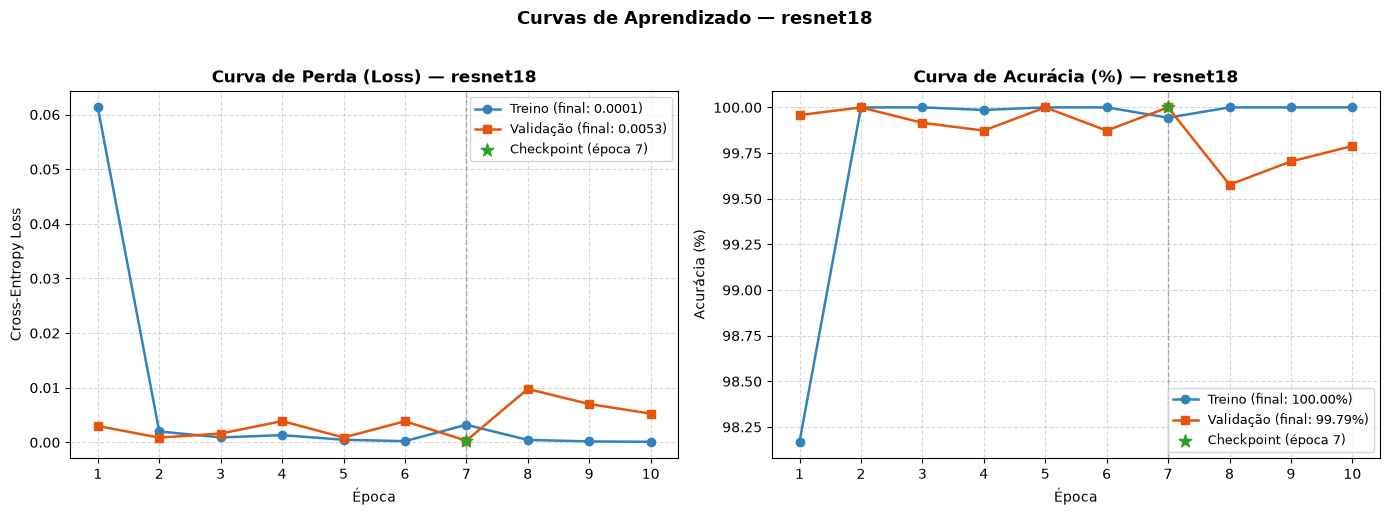

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===
              precision    recall  f1-score   support

        ball     0.9979    0.9958    0.9968       473
  inner_race     0.9958    0.9979    0.9968       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     1.0000    1.0000    1.0000       475

    accuracy                         0.9987      2368
   macro avg     0.9984    0.9984    0.9984      2368
weighted avg     0.9987    0.9987    0.9987      2368

[INFO] Figura salva em: ../../docs/images/confusion_matrix_resnet.png


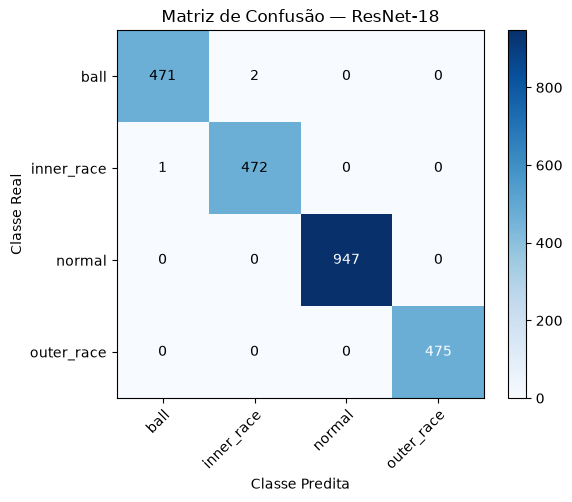

In [3]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_resnet['history'], 'resnet18',
                      save_path='../../docs/images/training_curves_resnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===')
print(classification_report(res_resnet['test_labels'], res_resnet['test_preds'], target_names=res_resnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_resnet, 'ResNet-18', save_path='../../docs/images/confusion_matrix_resnet.png')


## 3. Experimento 2: Inception-v3

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **Inception-v3** (com imagens redimensionadas para $299 \times 299$).

In [4]:
# Treinamento do Inception-v3
res_inception = train_and_evaluate_transfer_model('inception_v3', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['inception_v3'] = res_inception


[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.1287 - Acc: 96.83% | Val Loss: 0.0082 - Acc: 99.66% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0057 - Acc: 99.93% | Val Loss: 0.0009 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0044 - Acc: 99.93% | Val Loss: 0.0010 - Acc: 100.00% 
Época [04/10] | Treino Loss: 0.0064 - Acc: 99.85% | Val Loss: 0.0010 - Acc: 100.00% 
Época [05/10] | Treino Loss: 0.0039 - Acc: 99.90% | Val Loss: 0.0014 - Acc: 100.00% 
Época [06/10] | Treino Loss: 0.0008 - Acc: 100.00% | Val Loss: 0.0021 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0033 - Acc: 99.90% | Val Loss: 0.0017 - Acc: 99.96% 
Época [08/10] | Treino Loss: 0.0016 - Acc: 99.97% | Val Loss: 0.0011 - Acc: 100.00% 
Época [09/10] | Treino Loss: 0.0003 - Acc: 100.00% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 09/10.
Época

[INFO] Figura salva em: ../../docs/images/training_curves_inception.png


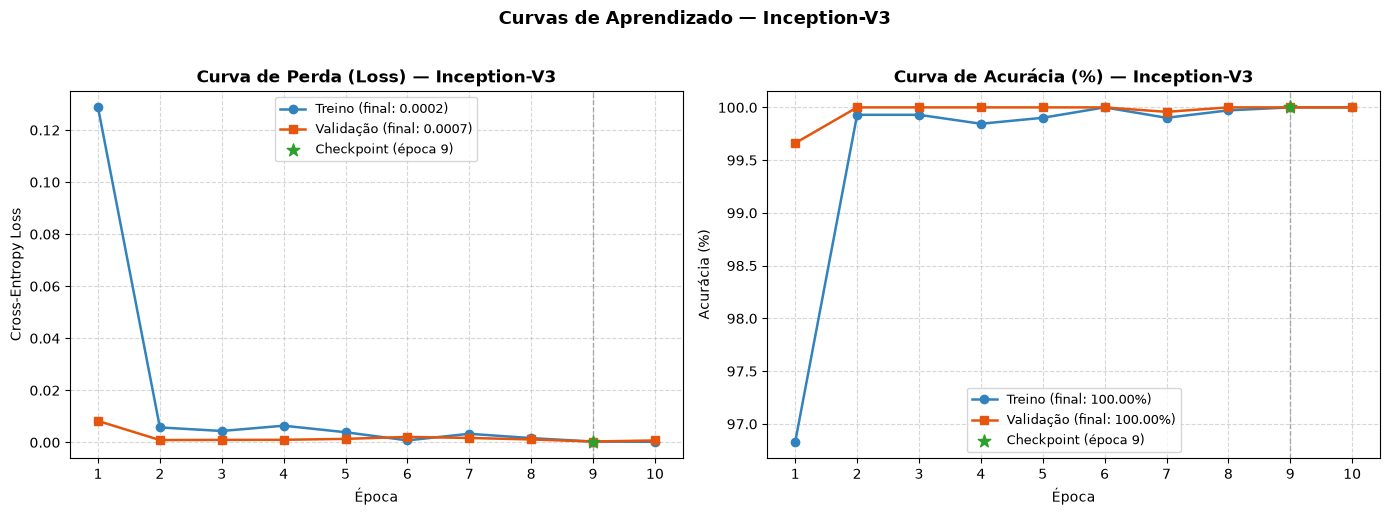

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===
              precision    recall  f1-score   support

        ball     0.8717    0.9915    0.9278       473
  inner_race     1.0000    0.8541    0.9213       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     0.9916    1.0000    0.9958       475

    accuracy                         0.9692      2368
   macro avg     0.9658    0.9614    0.9612      2368
weighted avg     0.9727    0.9692    0.9690      2368

[INFO] Figura salva em: ../../docs/images/confusion_matrix_inception.png


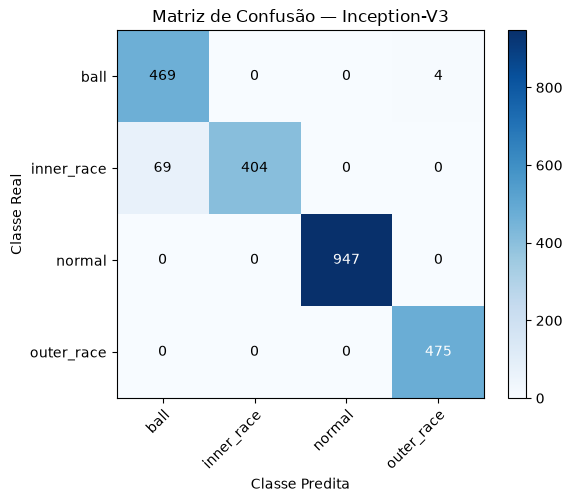

In [5]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_inception['history'], 'Inception-V3',
                      save_path='../../docs/images/training_curves_inception.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===')
print(classification_report(res_inception['test_labels'], res_inception['test_preds'], target_names=res_inception['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_inception, 'Inception-V3', save_path='../../docs/images/confusion_matrix_inception.png')

## 4. Experimento 3: EfficientNet-B0

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **EfficientNet-B0**.

In [6]:
# Treinamento do EfficientNet-B0
res_efficientnet = train_and_evaluate_transfer_model('efficientnet_b0', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['efficientnet_b0'] = res_efficientnet


[INFO] EXPERIMENTO TRANSFER LEARNING: EFFICIENTNET_B0 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.2837 - Acc: 94.42% | Val Loss: 0.0149 - Acc: 99.66% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0184 - Acc: 99.72% | Val Loss: 0.0063 - Acc: 99.92% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0081 - Acc: 99.87% | Val Loss: 0.0072 - Acc: 99.83% 
Época [04/10] | Treino Loss: 0.0060 - Acc: 99.92% | Val Loss: 0.0064 - Acc: 99.83% 
Época [05/10] | Treino Loss: 0.0046 - Acc: 99.92% | Val Loss: 0.0006 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0022 - Acc: 99.97% | Val Loss: 0.0017 - Acc: 99.96% 
Época [07/10] | Treino Loss: 0.0036 - Acc: 99.94% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0016 - Acc: 99.97% | Val Loss: 0.0020 - Acc: 99.96% 
Época [09/10] | Treino Loss: 0.0010 - Acc: 99.

[INFO] Figura salva em: ../../docs/images/training_curves_efficientnet.png


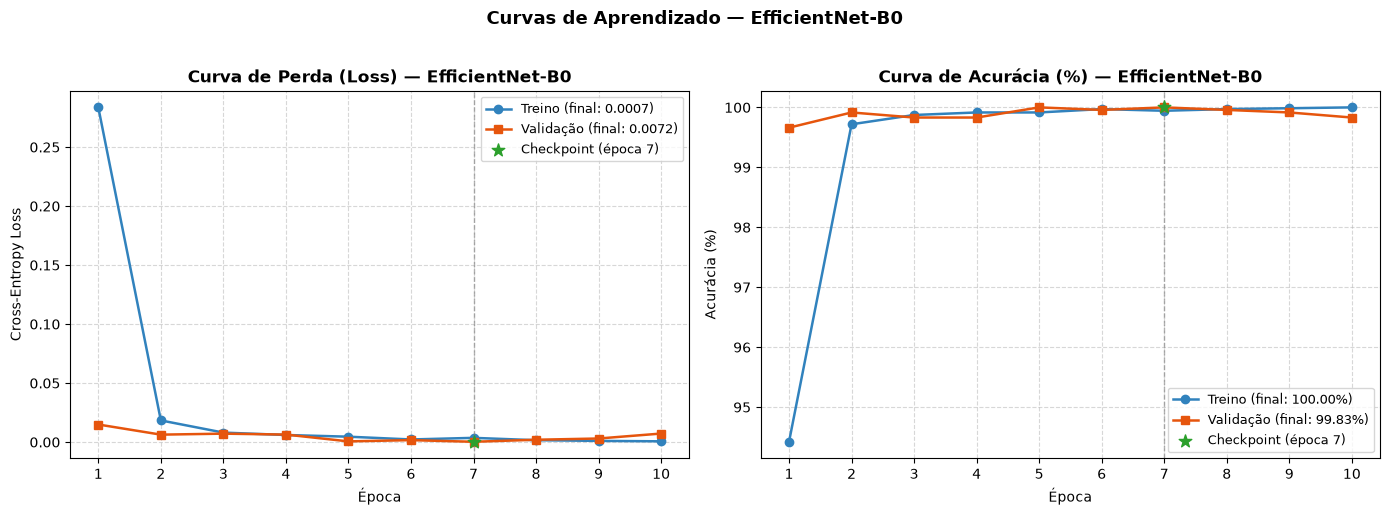

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===
              precision    recall  f1-score   support

        ball     0.9588    0.9852    0.9718       473
  inner_race     0.9978    0.9577    0.9773       473
      normal     1.0000    1.0000    1.0000       947
  outer_race     0.9875    1.0000    0.9937       475

    accuracy                         0.9886      2368
   macro avg     0.9860    0.9857    0.9857      2368
weighted avg     0.9888    0.9886    0.9886      2368

[INFO] Figura salva em: ../../docs/images/confusion_matrix_efficientnet.png


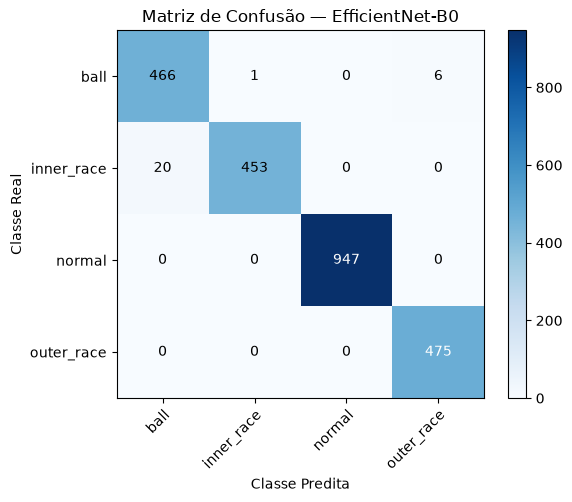

In [7]:
# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_efficientnet['history'], 'EfficientNet-B0',
                      save_path='../../docs/images/training_curves_efficientnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===')
print(classification_report(res_efficientnet['test_labels'], res_efficientnet['test_preds'], target_names=res_efficientnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
plot_confusion_matrix(res_efficientnet, 'EfficientNet-B0', save_path='../../docs/images/confusion_matrix_efficientnet.png')

## 5. Tabela Comparativa Geral de Desempenho 



In [8]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')

 TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) 
Modelo                 | Estratégia       | Acurácia Val (%)   | Acurácia Teste (%)
--------------------------------------------------------------------------------
RESNET18               | Transfer Learning | 100.00           % | 99.87            %
INCEPTION_V3           | Transfer Learning | 100.00           % | 96.92            %
EFFICIENTNET_B0        | Transfer Learning | 100.00           % | 98.86            %
